## Plots for WP4: Comparison of characteristics 

Notebook generating plot describing the detection characteristics of OncoRay runs NOVO51, NOVO139 and NOVO140

The purpose is to compare these data with Sara's plots shown in the WP4-meeting of 25.03.26

Script requirements:
- mgdraw_output_reader_NOVO_v03.py (DetectionDataStorage)
- mgdraw_txt_file_reader_06.py (collect_txt_data)

Will output plots:
1) Gamma and neutron spectra for PMMA positions for each scintillator bar (2 x 12 plots) [mimic Sara]
2) Gamma to neutron ratio for all scintillator bars as a function of PMMA phantom position (1 plot) [mimic Sara]
3) Gamma and neutron rate for all scintillator bar as a function of PMMA phantom position (1 plot) [mimic Sara]

4) Double neutron and triple gamma-ray events as a function of PMMA phantom position (1 plot)
5) Estimated hits lost by assuming the deadtime to be a "killzone" as a function of beam current (1 plot)
6) 2PG / 3PG / 2FN / 3FN counts (1 plot)
7) Layer/scintillator combinations (3 plots)

In [ ]:
# Standard import and initiation stuff
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage
from mgdraw_txt_file_reader_06 import collect_txt_data

primaries_per_spawn = 1.5e7
number_of_files = 70    

beam_current = 2.0 # nA

total_number_of_primaries = number_of_files * primaries_per_spawn  # 70 x 1.5e7 = 1.05e9 primaries
proton_charge = 1.6e-19 # Coloumbs
primaries_per_second = (beam_current * 1e-9) / proton_charge # 1.25e10 protons/sec for beam current 2 nA
time_elapsed = total_number_of_primaries / primaries_per_second

0.08399999999999999
0.08333333333333333 5


In [16]:
main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2"

files = ["132", "133"]

for run in files:
    PATH = main_PATH + rf"\NOVO{run}\scintillator_interactions"

    a = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=number_of_files)
    a.load_data(mgdraw_version_8_plus=True)
    a.filter_hits(beam_current=beam_current, write_hits_to_file=True)
    a.event_builder(write_ngimager_file=True)

Reading 70 scintillator_interactions.txt-files
Line:  3088015 300  8  8  0  6 12    0.000000   0.000000   53.86576   2.54455  24.80716     2   78 ***********  -4.692955  -4.941952  10.897378   0.003564

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO132/scintillator_interactions/OncoRay132_model_spawn_11001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  3088015 300  8  8  0  6 12    0.000000   0.000000   53.83627   2.26128  24.97947     2   79 ***********  -4.692955  -4.941952  10.897378   0.003564

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO132/scintillator_interactions/OncoRay132_model_spawn_11001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  3088015 300  8  8  0  6 12    0.000000   0.000000   53.90708   2.30133  24.94407     2  

#### Import files
- NOVO51: +0 mm
- NOVO139: -167 mm
- NOVO140: +183 mm

Cell takes about 1 minute to run

In [3]:
main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\2025-12_OncoRay_round2"

files = {"NOVO51": None, "NOVO139": None, "NOVO140": None}

for run in files:
    PATH = main_PATH + rf"\{run}\scintillator_interactions"

    files[run] = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=number_of_files)
    files[run].load_data(mgdraw_version_8_plus=True)
    files[run].filter_hits(beam_current=beam_current, write_hits_to_file=False)
    files[run].event_builder(write_ngimager_file=False)

Reading 70 scintillator_interactions.txt-files
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.23001  -2.79292  16.76584     9   35 ***********   3.827359   6.436274   7.202403   0.000821

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO51/scintillator_interactions/OncoRay51_model_spawn_17001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.17122  -2.20173  16.42816     9   37 ***********   3.827359   6.436274   7.202403   0.000821

*********** found in file <_io.TextIOWrapper name='C:/Users/sathu8821/OneDrive - University of Bergen/NOVO/PTB model/Simulations/2025-12_OncoRay_round2/NOVO51/scintillator_interactions/OncoRay51_model_spawn_17001_scintillator_interactions.txt' mode='r' encoding='utf-8'>
Line:  6083730 300  8  8  0  1 -2    0.000000   0.000000   73.67462  -2.34834  16.38493     9   38 

## Plot 1: Energy deposition spectra

C:\Users\sathu8821\AppData\Local\Temp\ipykernel_31772\2448673687.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


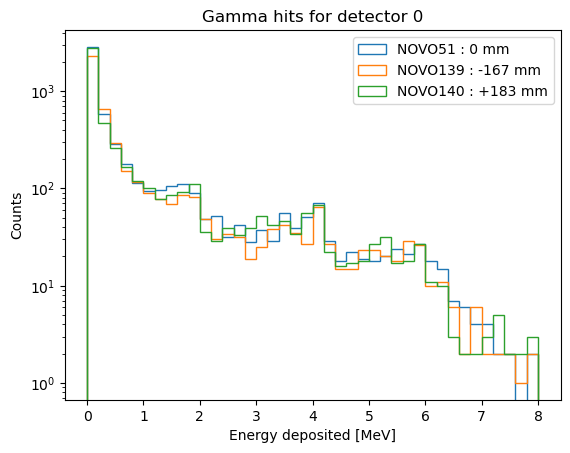

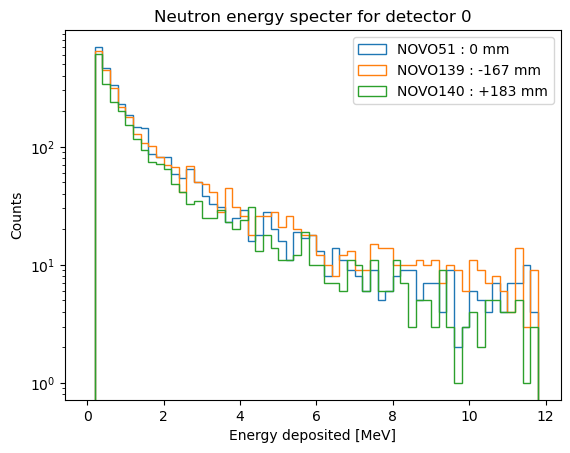

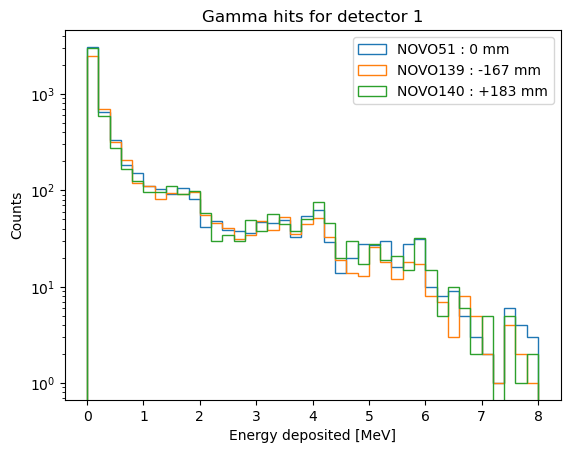

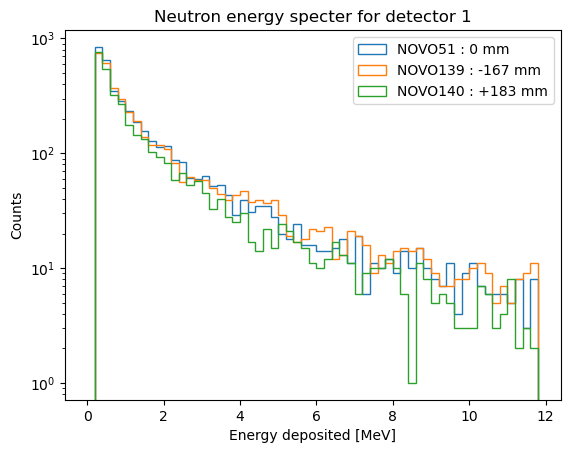

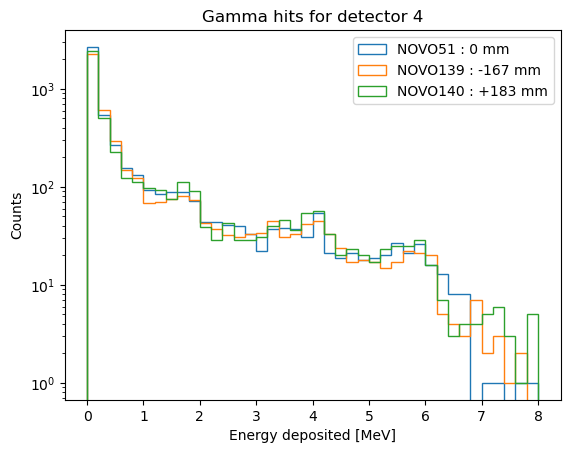

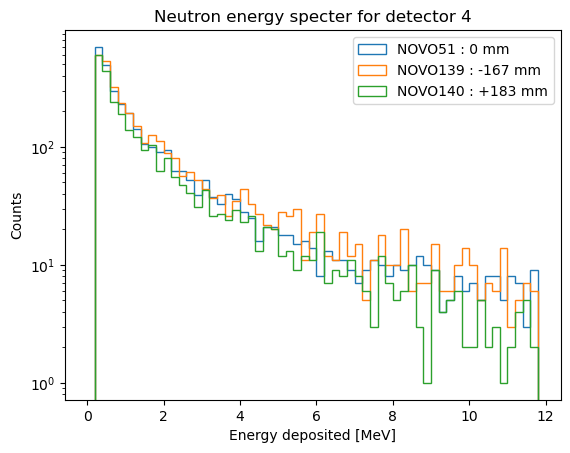

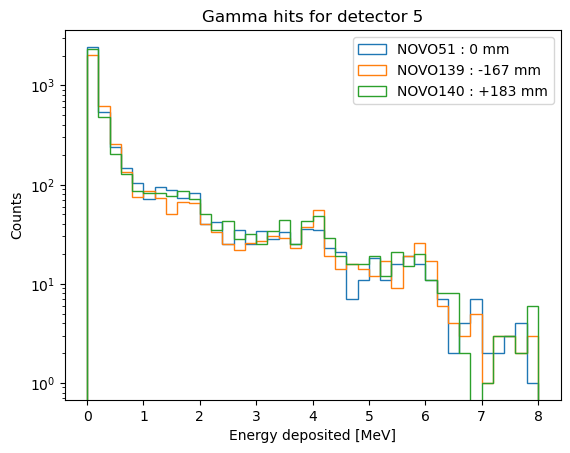

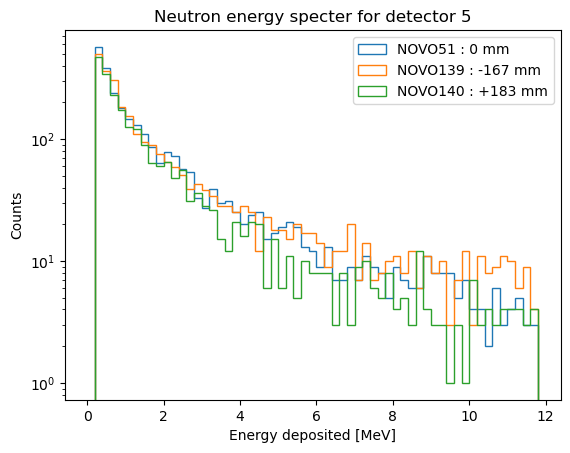

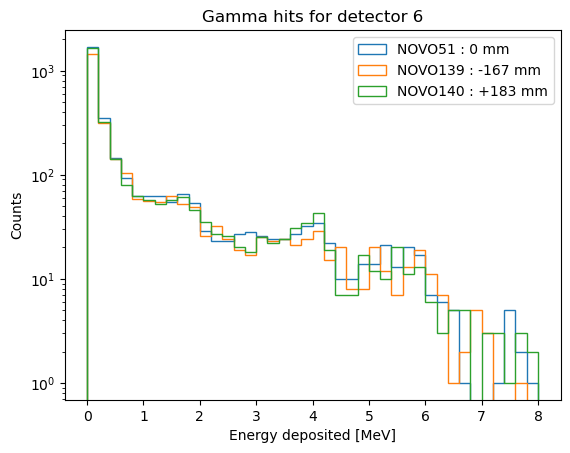

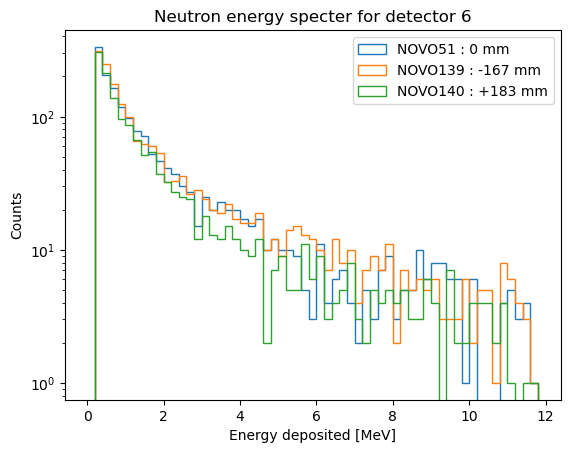

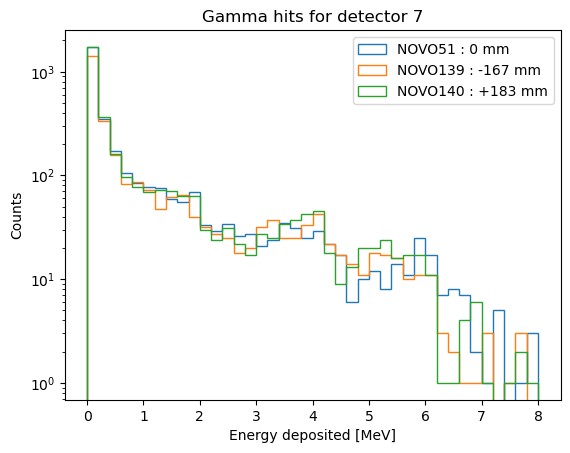

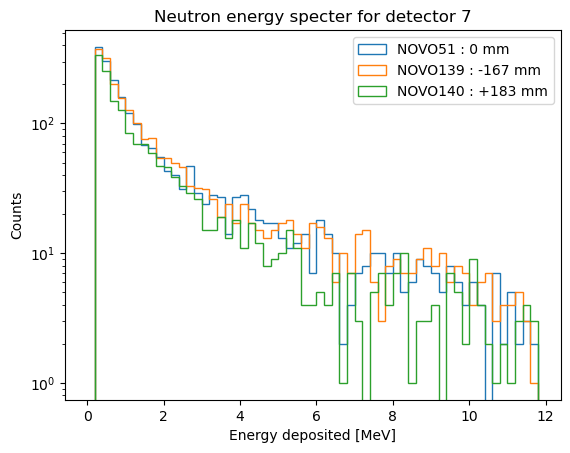

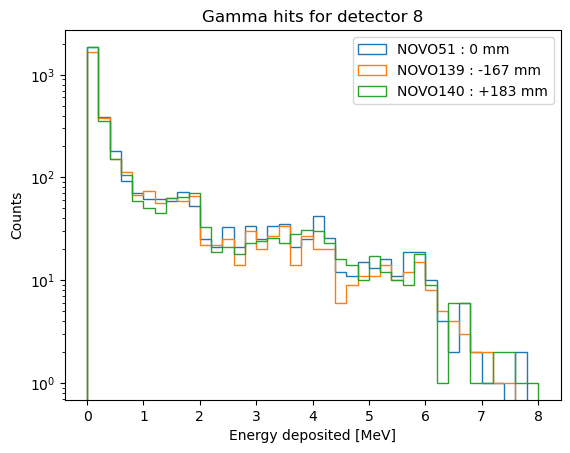

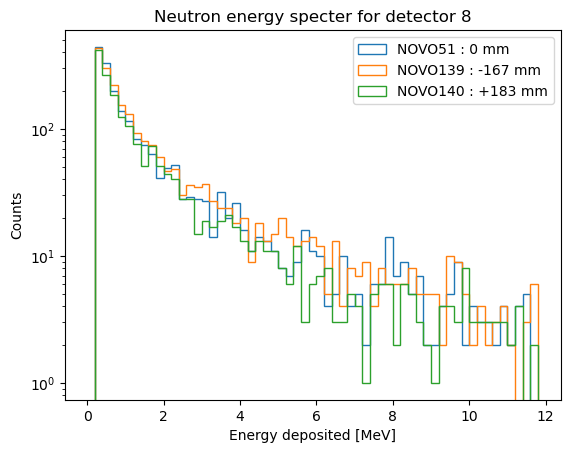

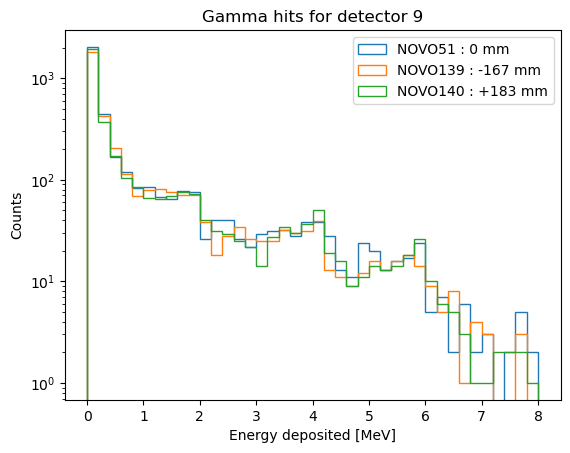

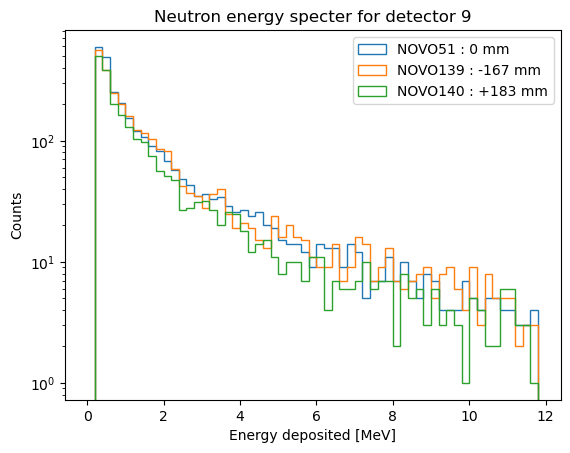

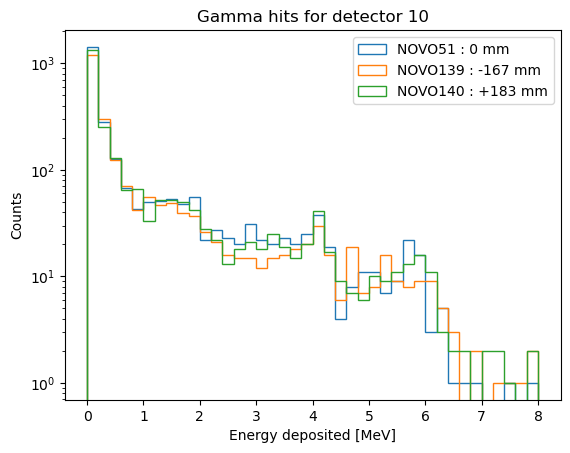

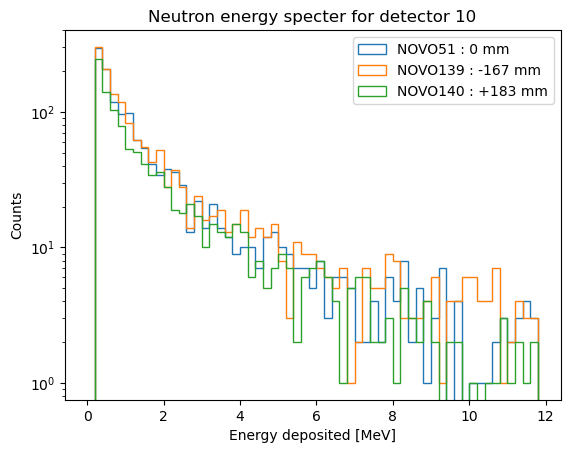

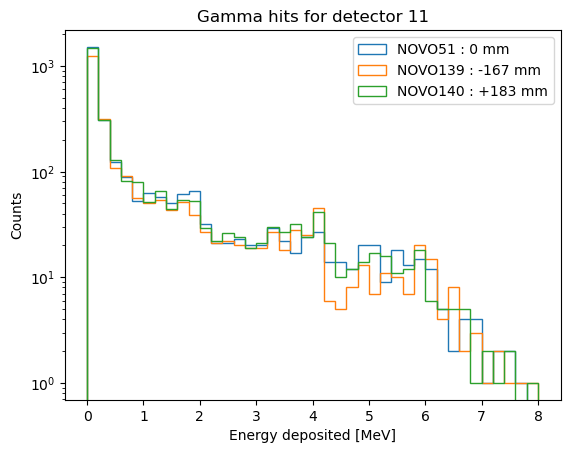

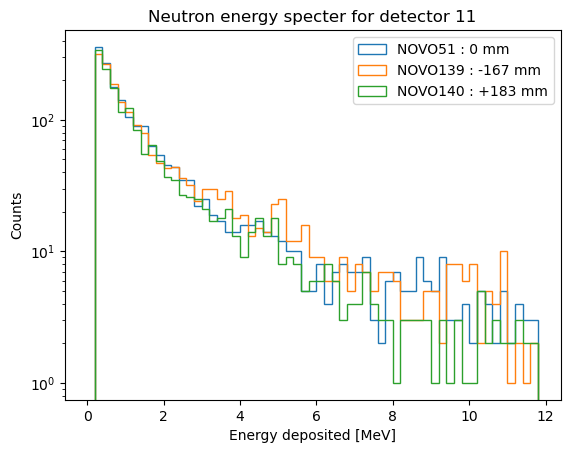

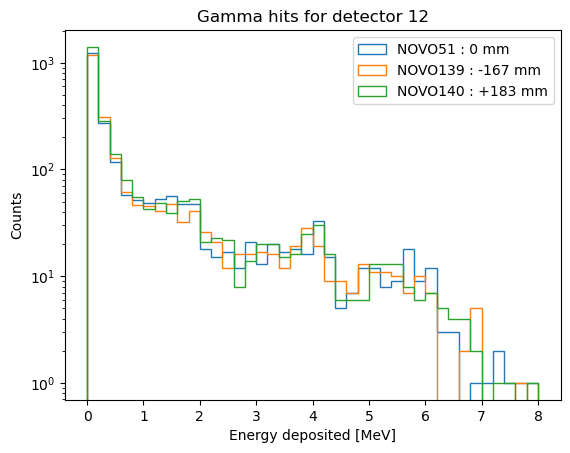

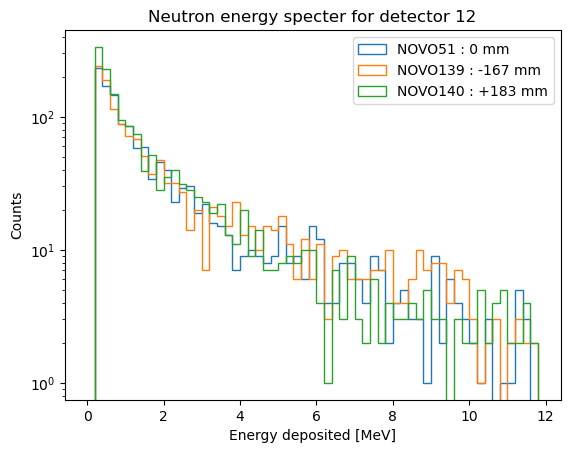

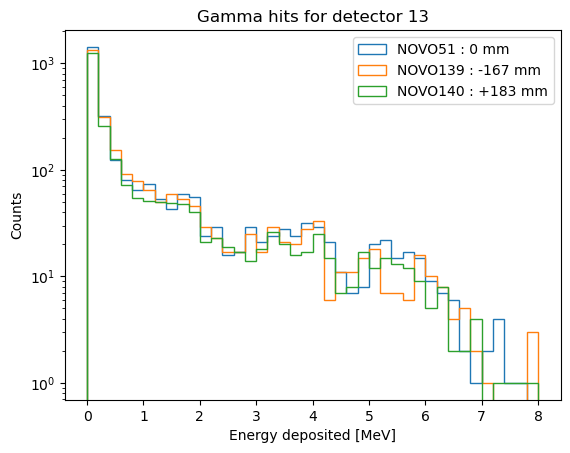

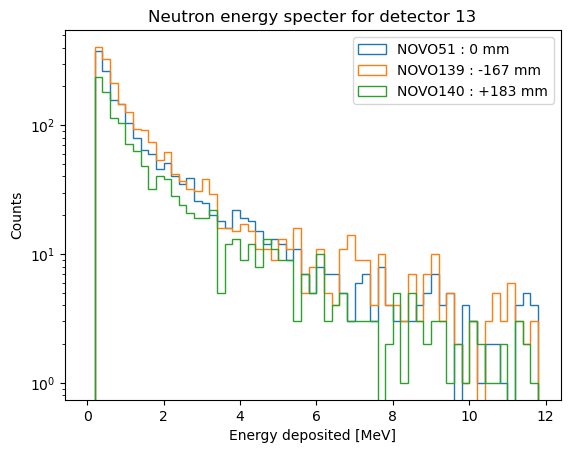

In [10]:
bin_width = 0.2 # MeV
max_energy = 8.0 # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)

neutron_bins = np.arange(0.0, 12.0, bin_width)

label_helper = {"NOVO51": " : 0 mm", "NOVO139": " : -167 mm", "NOVO140": " : +183 mm"}
region_label_helper = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

for region in range(1, 13):

    # Gamma plot
    plt.figure()

    for file in files:
        gamma_hits = files[file].gamma_hits[:, 7]   # Energy depositions
        gamma_regions = files[file].gamma_hits[:, 12]   # Regions
        gamma_region_mask = gamma_regions==region
        gamma_region_hits = gamma_hits[gamma_region_mask]

        plt.hist(gamma_region_hits, bins, label=file+label_helper[file], histtype="step", density=False)

        plt.xlabel("Energy deposited [MeV]")
        plt.ylabel("Counts")
        plt.yscale("log")

        plt.title(f"Prompt gamma energy specter for detector {region_label_helper[region - 1]}")
        plt.title(f"Gamma hits for detector {region_label_helper[region - 1]}")
        plt.legend()


    # Neutron plot
    plt.figure()

    for file in files:
        neutron_hits = files[file].neutron_hits[:, 7]   # Energy depositions
        neutron_regions = files[file].neutron_hits[:, 12]   # Regions
        neutron_region_mask = neutron_regions==region
        neutron_region_hits = neutron_hits[neutron_region_mask]

        plt.hist(neutron_region_hits, neutron_bins, label=file+label_helper[file], histtype="step")
        
        plt.xlabel("Energy deposited [MeV]")
        plt.ylabel("Counts")
        plt.yscale("log")

        plt.title(f"Neutron energy specter for detector {region_label_helper[region - 1]}")
        plt.legend()

    """
    # Gamma plot (normalized)
    plt.figure()
    for file in files:
        gamma_hits = files[file].gamma_hits[:, 7]   # Energy depositions
        gamma_regions = files[file].gamma_hits[:, 12]   # Regions
        gamma_region_mask = gamma_regions==region
        gamma_region_hits = gamma_hits[gamma_region_mask]

       counts, edges = np.histogram(gamma_region_hits, bins)

        # Approach 1) Norm by bin width
       norm_by_width = counts / bin_width

        # Apporach 2) Norm by bin center
        bin_centers = (edges[-1] + edges[1:]) / 2
        norm_by_center = counts/bin_centers

        plt.bar(edges[:-1], norm_by_width, width=bin_width, align="edge", label=file+label_helper[file])

        plt.xlabel("Energy deposited [MeV]")
        plt.ylabel("Counts")
        plt.yscale("log")

        plt.title(f"Prompt gamma energy specter for detector {region_label_helper[region - 1]}")
        plt.legend()
    """


## Plot 2: Gamma to neutron ratio

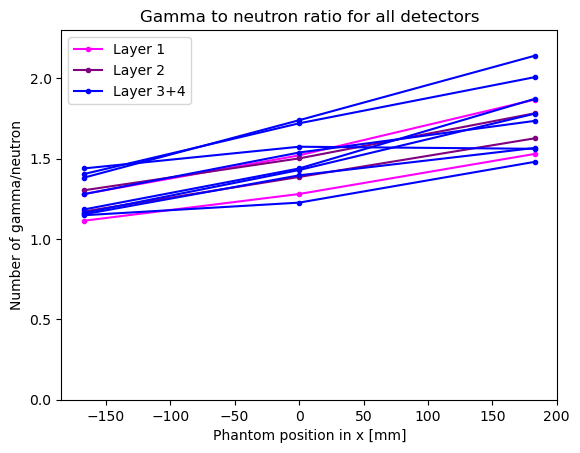

In [161]:
plt.figure()

Xs = np.array([0, -167, +183])
idx_sort = np.argsort(Xs)
sorted_Xs = Xs[idx_sort]

part_ratios = []

for file in files:
    gamma_regions = files[file].gamma_hits[:, 12]
    neutron_regions = files[file].neutron_hits[:, 12]

    ratio_per_bar = []

    # Loop through all regions
    for region in range(1, 13):
        gamma_mask = gamma_regions==region
        neutron_mask = neutron_regions==region

        num_gammas = sum(gamma_mask)
        num_neutrons = sum(neutron_mask)

        gamma_to_neutron_ratio = num_gammas/num_neutrons
        ratio_per_bar.append(gamma_to_neutron_ratio)

    part_ratios.append(ratio_per_bar)

part_ratios = np.array(part_ratios)

for region in range(1, 13):

    
    Ys = part_ratios[:, region - 1]
    sorted_Ys = Ys[idx_sort]

    # Plotting Layer 1
    if region <= 2:
        plt.plot(sorted_Xs, sorted_Ys, marker=".", color="magenta", label="Layer 1")

    # Plotting Layer 2
    elif region <= 4:
        plt.plot(sorted_Xs, sorted_Ys, marker=".", color="purple", label="Layer 2")

    # Plotting Layer 3+4
    else:
        plt.plot(sorted_Xs, sorted_Ys, marker=".", color="blue", label="Layer 3+4")

plt.xlabel("Phantom position in x [mm]")
plt.ylabel("Number of gamma/neutron")
plt.title("Gamma to neutron ratio for all detectors")
plt.ylim([0, 2.3])

# Legend fixing
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys())

## Plot 3: Particle rates

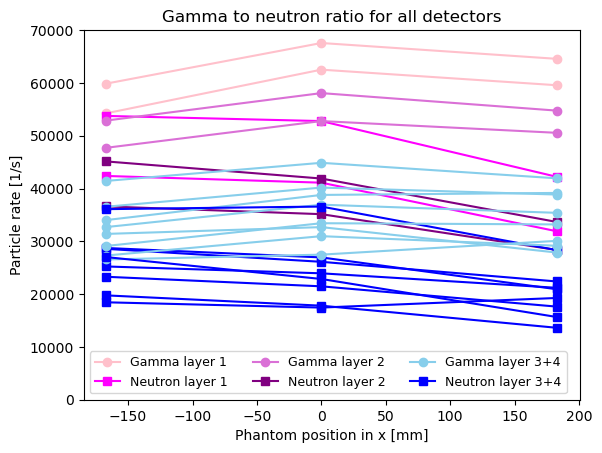

In [168]:
plt.figure()

Xs = np.array([0, -167, +183])
idx_sort = np.argsort(Xs)
sorted_Xs = Xs[idx_sort]

gamma_rates = []
neutron_rates = []

for file in files:
    gamma_regions = files[file].gamma_hits[:, 12]
    neutron_regions = files[file].neutron_hits[:, 12]

    gamma_rate_per_bar = []
    neutron_rate_per_bar = []

    # Loop through all regions
    for region in range(1, 13):
        gamma_mask = gamma_regions==region
        neutron_mask = neutron_regions==region

        num_gammas = sum(gamma_mask)
        num_neutrons = sum(neutron_mask)

        gamma_rate_per_bar.append(num_gammas)
        neutron_rate_per_bar.append(num_neutrons)

    gamma_rates.append(gamma_rate_per_bar)
    neutron_rates.append(neutron_rate_per_bar)

gamma_rates = np.array(gamma_rates) / time_elapsed
neutron_rates = np.array(neutron_rates) / time_elapsed

# Scaling rates per second

for region in range(1, 13):

    Ys_gamma = gamma_rates[:, region - 1]
    Ys_neutron = neutron_rates[:, region - 1]

    sorted_Ys_gamma = Ys_gamma[idx_sort]
    sorted_Ys_neutron = Ys_neutron[idx_sort]


    # Plotting Layer 1
    if region <= 2:
        #plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="red", label="Gamma layer 1")
        #plt.plot(sorted_Xs, sorted_Ys_neutron, marker="x", color="orange", label="Neutron layer 1")

        # Colors to mimic Sara's plots
        plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="pink", label="Gamma layer 1")
        plt.plot(sorted_Xs, sorted_Ys_neutron, marker="s", color="magenta", label="Neutron layer 1")
        

    # Plotting Layer 2
    elif region <= 4:
        #plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="green", label="Gamma layer 2")
        #plt.plot(sorted_Xs, sorted_Ys_neutron, marker="s", color="lime", label="Neutron layer 2")

        # Colors to mimic Sara's plots
        plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="orchid", label="Gamma layer 2")
        plt.plot(sorted_Xs, sorted_Ys_neutron, marker="s", color="purple", label="Neutron layer 2")

    # Plotting Layer 3+4
    else:
        #plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="blue", label="Gamma layer 3+4")
        #plt.plot(sorted_Xs, sorted_Ys_neutron, marker="s", color="purple", label="Neutron layer 3+4")

        # Colors to mimic Sara's plots
        plt.plot(sorted_Xs, sorted_Ys_gamma, marker="o", color="SkyBlue", label="Gamma layer 3+4")
        plt.plot(sorted_Xs, sorted_Ys_neutron, marker="s", color="blue", label="Neutron layer 3+4")

plt.xlabel("Phantom position in x [mm]")
plt.ylabel("Particle rate [1/s]")
plt.title("Gamma to neutron ratio for all detectors")
plt.ylim([0, 70000])

# Legend fixing
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys(), ncols=3, fontsize=9)

## Plot 4: Double neutron and triple gamma rates

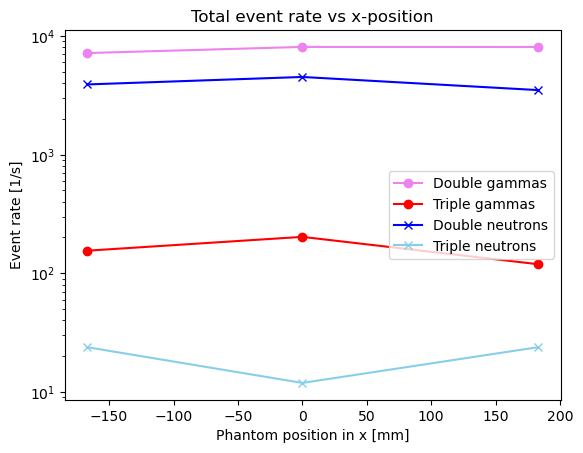

In [163]:
plt.figure()

Xs = np.array([0, -167, +183])
idx_sort = np.argsort(Xs)
sorted_Xs = Xs[idx_sort]

Ys_double_gamma = []
Ys_triple_gamma = []
Ys_double_neutron = []
Ys_triple_neutron = []

for file in files:
    num_double_gamma_events = len(files[file].double_gamma_events)
    num_triple_gamma_events = len(files[file].triple_gamma_events)
    num_double_neutron_events = len(files[file].double_neutron_events)
    num_triple_neutron_events = len(files[file].triple_neutron_events)

    Ys_double_gamma.append(num_double_gamma_events)
    Ys_triple_gamma.append(num_triple_gamma_events)
    Ys_double_neutron.append(num_double_neutron_events)
    Ys_triple_neutron.append(num_triple_neutron_events)

# Converting to numpy
Ys_double_gamma = np.array(Ys_double_gamma)
Ys_triple_gamma = np.array(Ys_triple_gamma)
Ys_double_neutron = np.array(Ys_double_neutron)
Ys_triple_neutron = np.array(Ys_triple_neutron)

# Scaling total counts to count rates
Ys_double_gamma = Ys_double_gamma / time_elapsed
Ys_triple_gamma = Ys_triple_gamma / time_elapsed
Ys_double_neutron = Ys_double_neutron / time_elapsed
Ys_triple_neutron = Ys_triple_neutron / time_elapsed

# Sorting order
sorted_Ys_double_gamma = Ys_double_gamma[idx_sort]
sorted_Ys_triple_gamma = Ys_triple_gamma[idx_sort]
sorted_Ys_double_neutron = Ys_double_neutron[idx_sort]
sorted_Ys_triple_neutron = Ys_triple_neutron[idx_sort]


# Plotting gammas and neutrons
plt.plot(sorted_Xs, sorted_Ys_double_gamma, marker="o", label="Double gammas", color="violet")
plt.plot(sorted_Xs, sorted_Ys_triple_gamma, marker="o", label="Triple gammas", color="red")
plt.plot(sorted_Xs, sorted_Ys_double_neutron, marker="x", label="Double neutrons", color="blue")
plt.plot(sorted_Xs, sorted_Ys_triple_neutron, marker="x", label="Triple neutrons", color="SkyBlue")


plt.xlabel("Phantom position in x [mm]")
plt.ylabel("Event rate [1/s]")
plt.title("Total event rate vs x-position")
plt.legend()
#plt.ylim([0, 1000])
plt.yscale("log")

## Plot 5: Hits that should be lost due to deadtime

In [164]:
def estimate_hits_lost(hit_list, deadtime):
    """Helper function for plotting deadtime effects"""
    hit_statistics = []

    all_hits_regions = hit_list[:, 12]
    all_hits_times = hit_list[:, 14]

    for region_val in range(1, 13):
        previous_hit_time = -100    # [µs]: Default starting value

        region_mask = all_hits_regions==region_val  # mask to filter out hit times occuring in the selected regions
        region_hit_times = all_hits_times[region_mask]
        sorted_region_times = np.sort(region_hit_times) # Sorting hit times from lowest to highest

        clean_hits_in_region = 0    # Iterative variable to count clean hits
        total_hits_in_region = sum(region_mask) # Total number of hits excluding deadtimes
        hits_lost_in_region = 0

        for time in sorted_region_times:

            if time > previous_hit_time + deadtime:
                clean_hits_in_region += 1
                previous_hit_time = time

            else:
                hits_lost_in_region += 1

        percentage_hits_lost = hits_lost_in_region / total_hits_in_region
        
        hit_statistics.append([total_hits_in_region, clean_hits_in_region, hits_lost_in_region, percentage_hits_lost])

    return np.array(hit_statistics)

[12.67657536 13.70727231 12.25789679]
[15.18406507 15.10812679 13.70320856]
[12.30787849 13.46565248 11.4489439 ]
[10.73589419 11.62790698 10.42325651]
[7.94828317 7.78771858 7.46804216]
[9.11153119 8.70822042 8.35478123]
[8.91359825 9.51612903 8.37055739]
[10.40391677 11.30587204  9.43268417]
[6.15850581 6.92007797 5.53546592]
[7.36773065 7.96936452 7.54758259]
[6.31911532 6.2715004  7.01035895]
[8.60630722 8.60261074 5.93382554]


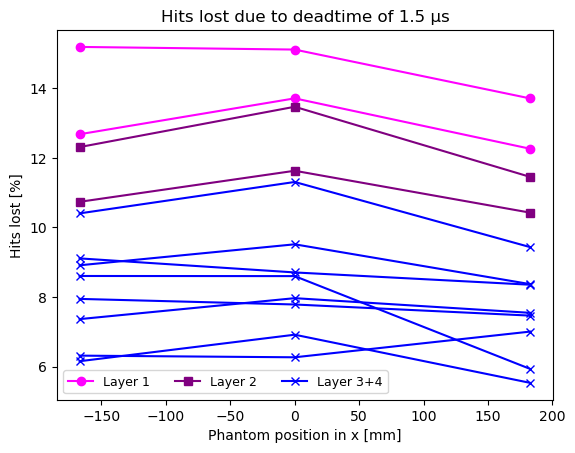

In [165]:
deadtime_statistics = {"NOVO51": None, "NOVO139": None, "NOVO140": None}
hit_deadtime = 1.5 # [µs]

for file in deadtime_statistics:
    deadtime_statistics[file] = estimate_hits_lost(files[file].all_hits, hit_deadtime)

plt.figure()

Xs = np.array([0, -167, +183])
idx_sort = np.argsort(Xs)
sorted_Xs = Xs[idx_sort]

for region in range(1, 13):
    Ys_percentage_lost = []

    for file, vals in deadtime_statistics.items():
        Ys_percentage_lost.append(vals[:, 3][region - 1])

    Ys_percentage_lost = 100 * np.array(Ys_percentage_lost)[idx_sort]
    print(Ys_percentage_lost)

    # Plotting Layer 1
    if region <= 2:
        plt.plot(sorted_Xs, Ys_percentage_lost, marker="o", color="magenta", label="Layer 1")
        

    # Plotting Layer 2
    elif region <= 4:
        plt.plot(sorted_Xs, Ys_percentage_lost, marker="s", color="purple", label="Layer 2")

    # Plotting Layer 3+4
    else:
        plt.plot(sorted_Xs, Ys_percentage_lost, marker="x", color="blue", label="Layer 3+4")

plt.xlabel("Phantom position in x [mm]")
plt.ylabel("Hits lost [%]")
plt.title(f"Hits lost due to deadtime of {hit_deadtime} µs")


# Legend fixing
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys(), ncols=3, fontsize=9)

## Gamma data for Sara
Only gamma energy deposition data for detector 0 and 1 (region 1 and 2) in 6 .txt-files:

- NOVO51_dtc0.txt       +NOVO51_dtc1.txt;
- NOVO139_dtc0.txt      +NOVO139_dtc1.txt;
- NOVO140_dtc0.txt      +NOVO140_dtc1.txt;

In [178]:
bin_width = 0.05 # MeV
max_energy = 8.0 # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)

label_helper = {"NOVO51": " : 0 mm", "NOVO139": " : -167 mm", "NOVO140": " : +183 mm"}
region_label_helper = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

for region in [1, 2]:

    for run, data in files.items():
        gamma_hits = data.gamma_hits[:, 7]   # Energy depositions
        gamma_regions = data.gamma_hits[:, 12]   # Regions
        gamma_region_mask = gamma_regions==region
        gamma_region_hits = gamma_hits[gamma_region_mask]

        np.savetxt(rf"{main_PATH}\{run}\{run}_dtc{region - 1}.txt", gamma_region_hits, delimiter=";",fmt="%.6f", header="hit energy deposit [MeV]")
